> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 9: Clustering

In this lab, we return to the **SF Rent** dataset that we used in **Lab 4: Data Understanding** and **Lab 5: Exploratory Data Analysis (EDA)**.

This time, we’ll explore how to segment the counties using both:
- **Manual clustering** based on business rules
- **Automatic clustering** using KMeans clustering

Segmentation helps identify meaningful groups within data, such as counties with high rent burden or low affordability. This is valuable for making targeted decisions in housing policy, urban planning, and social support.


## Outline

- Load and inspect the SF Rents dataset  
- Engineer and prepare features  
- Create manual segments using binning  
- Perform KMeans clustering for automatic segments  
- Visualize and compare results  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_09_clustering.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Overview

**Dataset:** `rent.csv`  
Source: [TidyTuesday – 2022-07-05](https://github.com/rfordatascience/tidytuesday/blob/main/data/2022/2022-07-05/rent.csv)

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | 1 = room in apartment |
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data + Prepare for Segmentation

### Instructions:
- Import the `pandas` library.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.e structure and preview the data.
- Remove duplicates
- Handle missing values
- Remove outliers (for price, beds, baths, sqft)
- Fix data types
- Optionally impute or filter variables

In [1]:
import pandas as pd

# Load the dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

# Get a quick overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  str    
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  str    
 4   city         200796 non-null  str    
 5   county       199402 non-null  str    
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    str    
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  str    
 15  descr        3254 non-null    str    
 16  details      8015 non-null    str    
dtypes: float64(8), object(1), str(8)
memory usage: 26.0+ MB


/var/folders/st/mxnd0j9d72v3_qdzxw5s7bq40000gn/T/ipykernel_71520/2677054146.py:5: DtypeWarning: Columns (0: date) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [2]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


In [3]:
# STEP 1: Drop duplicates
df = df.drop_duplicates(subset='post_id')

# STEP 2: Drop rows with nulls in essential columns
essential = ['price', 'beds', 'baths', 'sqft', 'lat', 'lon']
df = df.dropna(subset=essential)

# STEP 3: Remove outliers (common-sense filtering)
df = df[df['price'].between(500, 20000)]
df = df[df['beds'].between(0, 10)]
df = df[df['baths'].between(0.5, 10)]
df = df[df['sqft'].between(100, 5000)]

# STEP 4: Convert data types if needed
df['beds'] = df['beds'].astype(int)
df['baths'] = df['baths'].astype(float)  # decimal values allowed
df['sqft'] = df['sqft'].astype(int)
df['price'] = df['price'].astype(int)

# STEP 5: Reset index
df = df.reset_index(drop=True)

# Preview cleaned data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1984 entries, 0 to 1983
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      1984 non-null   str    
 1   date         1984 non-null   object 
 2   year         1984 non-null   float64
 3   nhood        1984 non-null   str    
 4   city         1984 non-null   str    
 5   county       1979 non-null   str    
 6   price        1984 non-null   int64  
 7   beds         1984 non-null   int64  
 8   baths        1984 non-null   float64
 9   sqft         1984 non-null   int64  
 10  room_in_apt  1984 non-null   float64
 11  address      1768 non-null   str    
 12  lat          1984 non-null   float64
 13  lon          1984 non-null   float64
 14  title        1855 non-null   str    
 15  descr        1847 non-null   str    
 16  details      1873 non-null   str    
dtypes: float64(5), int64(3), object(1), str(8)
memory usage: 263.6+ KB


In [4]:
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,4817227421,20141223,2014.0,alameda,alameda,alameda,1939,2,1.0,864,0.0,NaN,37.770600,-122.264800,"LIVE MORE, DRIVE LESS! JUST ACROSS THE BAY FRO...","Summer House Apartments 1826 Poggi St, Alameda...","2BR / 1Ba 864ft2 apartment date=""2014-12-23"" ..."
1,4710888130,20141012,2014.0,alameda,alameda,alameda,2250,2,1.0,1080,0.0,659,37.772835,-122.248585,2br Victortian Duplex Garden Apt.,"This 1903 ""Workingman's Victorian"" on a quiet ...","2BR / 1Ba 1080ft2 apartment date=""2014-11-02""..."
2,5961989126,20170126,2017.0,alameda,alameda,alameda,3995,3,2.0,1787,0.0,NaN,37.759231,-122.247190,3 BR/2 BA Queene Anne on Park St.,This charming 1787 sq ft meticulously maintain...,"3BR / 2Ba1787ft2 data-date=""2017-02-01"" data-t..."
3,4935175730,20150316,2015.0,alameda,alameda,alameda,2536,2,2.0,1225,0.0,NaN,37.753609,-122.249081,Spacious 2BR/2BA in a Great Community!,Tower Apartments CALL US: show contact infox3...,"2BR / 2Ba 1225ft2 apartment date=""2015-04-19""..."
4,4988581576,20150421,2015.0,alameda,alameda,alameda,2650,2,1.0,950,0.0,497,37.758922,-122.263314,"Upgraded 2B w/ Pool View, Short Walk to School...",Enjoy and experience the relaxing atmosphere o...,"2BR / 1Ba 950ft2 apartment date=""2015-04-20"" ..."


## 2. Engineer and Prepare Features

We’ll select features for clustering:
- Property: `price`, `beds`, `baths`, `sqft`
- Geographic: `lat`, `lon`

We’ll standardize features to ensure fair weighting in distance-based clustering.

### Why This Matters:
Standardization avoids giving larger-scale variables (like `price`) more influence.

### Things to think about:
- Should all variables be scaled?
- Do geographic coordinates need standardization?


In [5]:
from sklearn.preprocessing import StandardScaler

# Select and scale features
features = ['price', 'beds', 'baths', 'sqft', 'lat', 'lon']
segment_df = df[features].copy()

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segment_df)

# Convert back to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=features)
scaled_df.head()


,price,beds,baths,sqft,lat,lon
0,-0.657774,-0.036416,-0.772941,-0.536093,0.429432,-0.403353
1,-0.473068,-0.036416,-0.772941,-0.165325,0.436382,-0.339893
2,0.563306,0.855552,0.682697,1.048255,0.394079,-0.334434
3,-0.303210,-0.036416,0.682697,0.083571,0.376597,-0.341835
4,-0.235504,-0.036416,-0.772941,-0.388473,0.393118,-0.397537


In [6]:
# What the scaler is actually correcting for, and what it costs on the map.
import numpy as np

print("Raw spread of each feature before scaling:")
for c in features:
    s = segment_df[c]
    print(f"  {c:6s} min {s.min():11.4f}   max {s.max():11.4f}"
          f"   range {s.max() - s.min():11.4f}   sd {s.std():9.4f}")

print(f"\nprice sd is {segment_df['price'].std() / segment_df['lat'].std():,.0f}x latitude's sd.")

# Standardizing lat and lon divides them by different numbers, which stretches the map.
lat_sd, lon_sd = segment_df["lat"].std(), segment_df["lon"].std()
km_ns = lat_sd * 110.95
km_ew = lon_sd * 111.32 * np.cos(np.radians(segment_df["lat"].mean()))
print(f"\nOne standard deviation north-south = {km_ns:5.1f} km")
print(f"One standard deviation east-west   = {km_ew:5.1f} km")
print(f"East-west distance is inflated {km_ns / km_ew:.2f}x once scaled.")


Raw spread of each feature before scaling:
  price  min    795.0000   max  19750.0000   range  18955.0000   sd 1684.1799
  beds   min      0.0000   max      7.0000   range      7.0000   sd    1.1214
  baths  min      1.0000   max      4.5000   range      3.5000   sd    0.6872
  sqft   min    117.0000   max   4800.0000   range   4683.0000   sd  582.7207
  lat    min     36.9102   max     39.0711   range      2.1609   sd    0.3217
  lon    min   -123.1965   max   -121.2120   range      1.9845   sd    0.2556

price sd is 5,236x latitude's sd.

One standard deviation north-south =  35.7 km
One standard deviation east-west   =  22.5 km
East-west distance is inflated 1.58x once scaled.


### 🔧 Reflection – Part 2

2.1 Why should lat/lon (latitude and longitude) be scaled before clustering? What would happen if they weren’t? (There’s no coding here, just write your response below.)

### ✍️ Your Response: 🔧

**2.1** KMeans measures distance, so the column with the biggest numbers wins. Price has a standard deviation of about $1,684 and latitude's is 0.32 degrees, roughly 5,200 to one. Unscaled, a $200 rent gap would outweigh the entire 2.16 degree spread of the data, which is most of northern California. The geographic clusters would come back as price clusters with a map drawn on them, and beds and baths would vanish for the same reason.

Scaling costs something here though, and it's worth naming. Latitude gets divided by 0.3217 and longitude by 0.2556, two different numbers, so the map stretches. One standard deviation north-south covers 35.7 km on the ground while one east-west covers 22.5 km, so an east-west gap ends up counting about 1.6 times more than the same real distance north-south. The clusters still work. The scatter plot just isn't a map anymore, which is why it doesn't look like the Bay Area.


## 3. Create Manual Segments Using Binning

Let’s group listings by price into:
- **Low**: < $2,000
- **Mid**: $2,000–$4,000
- **High**: > $4,000

### Why This Matters:
Manual bins based on thresholds offer simple segmentation — useful when business rules exist.

### Things to think about:
- Are fixed cutoffs better than percentiles?
- Should you also bin square footage?


In [7]:
# Create price segments
df['price_segment'] = pd.cut(
    df['price'],
    bins=[0, 2000, 4000, float('inf')],
    labels=['Low', 'Mid', 'High']
)

df['price_segment'].value_counts()


price_segment
Mid     1195
Low      493
High     296
Name: count, dtype: int64

### 🔧 Do the following – Part 3

1. Create a column called `sqft_segment` using bins:  
  - Small: `< 800`, Medium: `800–1400`, Large: `>1400`  
2. Count how many listings fall into each `sqft_segment` using `.value_counts()`  
3. Use `.head()` to preview both `price_segment` and `sqft_segment`

In [8]:
# Same three-bucket idea as price, applied to floor area.
df["sqft_segment"] = pd.cut(
    df["sqft"],
    bins=[0, 800, 1400, float("inf")],
    labels=["Small", "Medium", "Large"],
)

print(df["sqft_segment"].value_counts().reindex(["Small", "Medium", "Large"]).to_string())
print("\nprice_segment for comparison:")
print(df["price_segment"].value_counts().reindex(["Low", "Mid", "High"]).to_string())

df[["price", "price_segment", "sqft", "sqft_segment"]].head()


sqft_segment
Small     536
Medium    944
Large     504

price_segment for comparison:
price_segment
Low      493
Mid     1195
High     296


,price,price_segment,sqft,sqft_segment
0,1939,Low,864,Medium
1,2250,Mid,1080,Medium
2,3995,Mid,1787,Large
3,2536,Mid,1225,Medium
4,2650,Mid,950,Medium


## 4. Perform KMeans Clustering

We’ll create two sets of clusters:
1. **Feature-based** (price, beds, baths, sqft)
2. **Geographic-based** (lat, lon)

### Why This Matters:
Unsupervised clustering finds hidden patterns — useful for market segmentation, targeting, etc.

### Things to think about:
- How many clusters should you use?
- How do results differ between property and location clusters?


In [9]:
from sklearn.cluster import KMeans

# Select only the standardized property features
X_feat = scaled_df[['price', 'beds', 'baths', 'sqft']]

# Apply KMeans clustering with 4 clusters
kmeans_feat = KMeans(n_clusters=4, random_state=1)
scaled_df['feature_cluster'] = kmeans_feat.fit_predict(X_feat)

# Show number of listings in each cluster
scaled_df['feature_cluster'].value_counts()


feature_cluster
0    962
3    652
1    318
2     52
Name: count, dtype: int64

In [10]:
# Select only standardized geographic coordinates
X_geo = scaled_df[['lat', 'lon']]

# Apply KMeans clustering with 5 clusters
kmeans_geo = KMeans(n_clusters=5, random_state=1)
scaled_df['geo_cluster'] = kmeans_geo.fit_predict(X_geo)

# Show number of listings in each geographic cluster
scaled_df['geo_cluster'].value_counts()

geo_cluster
1    692
2    610
0    335
4    230
3    117
Name: count, dtype: int64

### 🔧 Do the following – Part 4

1. Run KMeans again using `k=3` (3 clusters instead of 4). Then compare the value counts of the old KMeans with your new KMeans.
2. Plot a histogram of `price` grouped by `feature_cluster`  

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Same four features, one fewer cluster.
kmeans_feat_3 = KMeans(n_clusters=3, random_state=1)
scaled_df["feature_cluster_k3"] = kmeans_feat_3.fit_predict(X_feat)

print("Cluster sizes, k=4:")
print(scaled_df["feature_cluster"].value_counts().sort_index().to_string())
print("\nCluster sizes, k=3:")
print(scaled_df["feature_cluster_k3"].value_counts().sort_index().to_string())


Cluster sizes, k=4:
feature_cluster
0    962
1    318
2     52
3    652

Cluster sizes, k=3:
feature_cluster_k3
0    1032
1     807
2     145


In [12]:
# Sizes on their own don't say much. Here is what each group is, in real dollars.
for name, col in [("k=4", "feature_cluster"), ("k=3", "feature_cluster_k3")]:
    prof = (df.assign(c=scaled_df[col].values)
              .groupby("c")[["price", "sqft", "beds", "baths"]].mean().round(1))
    prof["listings"] = scaled_df[col].value_counts().sort_index()
    print(f"--- {name} ---")
    print(prof.to_string())
    print()


--- k=4 ---
    price    sqft  beds  baths  listings
c                                       
0  2362.1   801.0   1.3    1.0       962
1  4175.8  1917.6   3.5    2.2       318
2  9497.0  2998.9   4.1    2.9        52
3  2991.1  1223.1   2.3    1.8       652

--- k=3 ---
    price    sqft  beds  baths  listings
c                                       
0  2411.7   824.2   1.3    1.1      1032
1  3165.7  1380.0   2.7    2.0       807
2  6901.4  2548.8   3.9    2.4       145



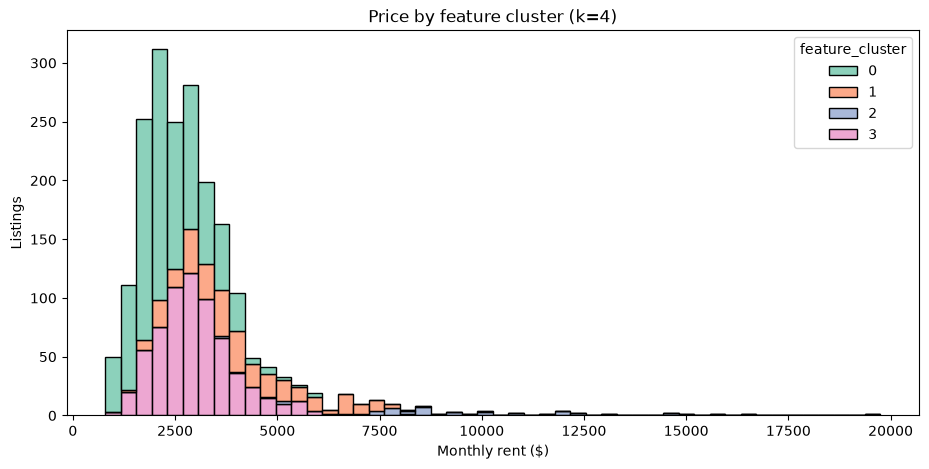

In [13]:
# Histogram of price by cluster, in real dollars rather than the standardized column.
plot_df = df.copy()
plot_df["feature_cluster"] = scaled_df["feature_cluster"].values

plt.figure(figsize=(11, 5))
sns.histplot(data=plot_df, x="price", hue="feature_cluster",
             bins=50, palette="Set2", multiple="stack")
plt.title("Price by feature cluster (k=4)")
plt.xlabel("Monthly rent ($)")
plt.ylabel("Listings")
plt.show()


## 5. Visualize and Compare Results

We’ll now visualize:
- Clusters on a map (lat/lon)
- Clusters in price vs sqft space

### Why This Matters:
Visual validation helps determine if clusters are interpretable and useful.

### Things to think about:
- Are location clusters geographically meaningful?
- Do property clusters separate by price or size?

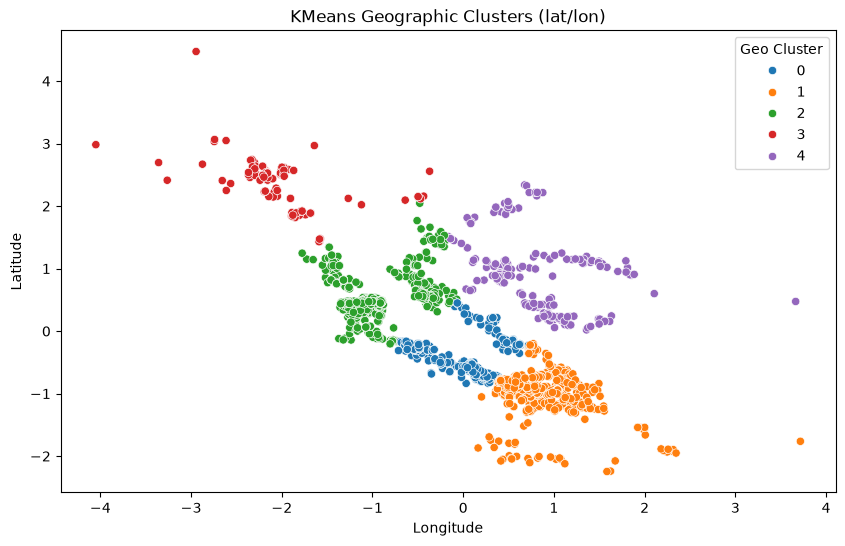

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot latitude vs longitude colored by geographic cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=scaled_df,
                x='lon',
                y='lat',
                hue='geo_cluster',
                palette='tab10')

plt.title("KMeans Geographic Clusters (lat/lon)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title='Geo Cluster')
plt.show()

In [15]:
# Do the geographic clusters line up with real places, or are they arbitrary?
print(pd.crosstab(scaled_df["geo_cluster"], df["county"]).to_string())


county       alameda  contra costa  marin  napa  san francisco  san mateo  santa clara  santa cruz  solano  sonoma
geo_cluster                                                                                                       
0                 77             0      0     0              4        134          120           0       0       0
1                 34             7      7     0             10          8          596          27       0       3
2                 82            39     56     4            333         62            1           0      32       0
3                  0             0      5     9              1          0            0           0       0     101
4                 69           119      0     0              2          0            1           0      36       0


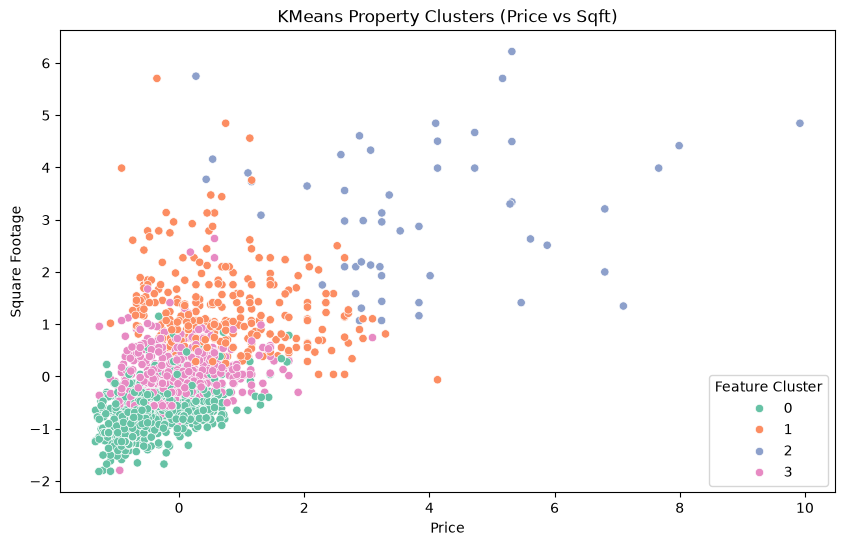

In [16]:
# Plot price vs square footage colored by feature cluster
plt.figure(figsize=(10,6))
sns.scatterplot(data=scaled_df,
                x='price',
                y='sqft',
                hue='feature_cluster',
                palette='Set2')

plt.title("KMeans Property Clusters (Price vs Sqft)")
plt.xlabel("Price")
plt.ylabel("Square Footage")
plt.legend(title='Feature Cluster')
plt.show()

### 🔧 Do the following – Part 5

In past assignments you’ve created scatterplots where the size of each point depended on how large each value was. And you’ve created scatterplots where the color of each point was assigned many or few colors. 

1. Add `beds` as the **point size** in your scatterplot of `price` vs `sqft`  
2. Add `baths` as the **point style** in your `sns.scatterplot()`  
3. Group by `feature_cluster` and calculate:
  - Average `price`
  - Average `sqft`
  - Average `beds`  


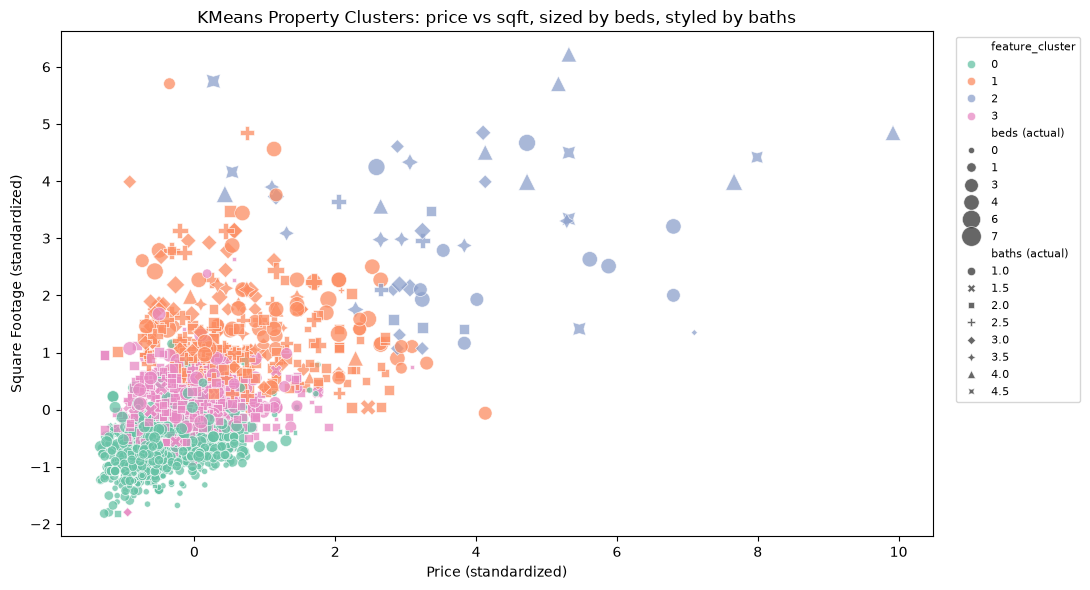

In [17]:
# beds and baths come from df, not scaled_df. A legend reading "size = -0.28 beds"
# would be useless, and style needs whole categories to put markers on.
plot_df = scaled_df.copy()
plot_df["beds (actual)"] = df["beds"].values
plot_df["baths (actual)"] = df["baths"].values

plt.figure(figsize=(11, 6))
sns.scatterplot(data=plot_df,
                x="price",
                y="sqft",
                hue="feature_cluster",
                size="beds (actual)",
                style="baths (actual)",
                palette="Set2",
                sizes=(20, 200),
                alpha=0.75)

plt.title("KMeans Property Clusters: price vs sqft, sized by beds, styled by baths")
plt.xlabel("Price (standardized)")
plt.ylabel("Square Footage (standardized)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


In [18]:
# Averages per cluster, in real units so the numbers mean something.
summary = (df.assign(feature_cluster=scaled_df["feature_cluster"].values)
             .groupby("feature_cluster")
             .agg(avg_price=("price", "mean"),
                  avg_sqft=("sqft", "mean"),
                  avg_beds=("beds", "mean"),
                  listings=("price", "size"))
             .round(1))
print(summary.to_string())


                 avg_price  avg_sqft  avg_beds  listings
feature_cluster                                         
0                   2362.1     801.0       1.3       962
1                   4175.8    1917.6       3.5       318
2                   9497.0    2998.9       4.1        52
3                   2991.1    1223.1       2.3       652


In [19]:
# The smallest cluster is the interesting one. Where are those listings?
smallest = scaled_df["feature_cluster"].value_counts().idxmin()
in_smallest = scaled_df["feature_cluster"] == smallest

sub = df.loc[in_smallest.values]
print(f"Cluster {smallest}: {in_smallest.sum()} listings, "
      f"mean rent ${sub['price'].mean():,.0f}, mean {sub['sqft'].mean():,.0f} sqft")
print(f"  rent runs ${sub['price'].min():,} to ${sub['price'].max():,}, median ${sub['price'].median():,.0f}")
print(f"  listings over $10,000 in the whole file: {(df['price'] > 10000).sum()}, "
      f"of which {(sub['price'] > 10000).sum()} are in this cluster")
print("\nCounty:")
print(sub["county"].value_counts().to_string())


Cluster 2: 52 listings, mean rent $9,497, mean 2,999 sqft
  rent runs $3,500 to $19,750, median $8,500
  listings over $10,000 in the whole file: 16, of which 16 are in this cluster

County:
county
san francisco    20
san mateo         9
santa clara       8
marin             7
contra costa      4
alameda           3
napa              1


Those 52 listings are the ones the walkthrough wondered about, and they're not rural. 20 are in San Francisco and 9 in San Mateo, so this is the expensive core of the Bay Area rather than large properties out past the city line.


## 6. Evaluate the Fit for your Clusters

We’ll now use three methods to evaluate the fit:
- WCSS
- Silhouette score
- Davies-bouldin index

### Why This Matters:
Clusters are difficult to visualize when they are based on more than 3 variables.  A statistical score will evaluate the fit across all of the variables.

### Things to think about:
- Lower WCSS = tighter, better-defined clusters
- Silhouette score ranges from -1 to 1.  Higher values = better clustering
- Lower Davies-Boulding Index = better clustering

### 🔧 Do the following – Part 6

Calculate the three scores for your **feature-based** cluster model by using the following methods:
- WCSS
- Silhouette score
- Davies-bouldin index

In [20]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Score the feature-based model. Lower WCSS is better, higher silhouette is
# better, lower Davies-Bouldin is better.
labels_k4 = scaled_df["feature_cluster"]

print("Feature-based model, k=4")
print(f"  WCSS (inertia)        {kmeans_feat.inertia_:9.2f}")
print(f"  Silhouette score      {silhouette_score(X_feat, labels_k4):9.4f}")
print(f"  Davies-Bouldin index  {davies_bouldin_score(X_feat, labels_k4):9.4f}")


Feature-based model, k=4
  WCSS (inertia)          3092.40


  Silhouette score         0.3349
  Davies-Bouldin index     1.2797


In [21]:
# The k=3 model from part 4, scored the same way, to see which k the numbers prefer.
rows = []
for k, model, labels in [(3, kmeans_feat_3, scaled_df["feature_cluster_k3"]),
                         (4, kmeans_feat, labels_k4)]:
    rows.append({"k": k,
                 "WCSS": round(model.inertia_, 2),
                 "silhouette": round(silhouette_score(X_feat, labels), 4),
                 "davies_bouldin": round(davies_bouldin_score(X_feat, labels), 4)})

print(pd.DataFrame(rows).to_string(index=False))
print("\nk=4 wins on WCSS and loses on the other two.")


 k    WCSS  silhouette  davies_bouldin
 3 3586.62      0.3875          1.1087
 4 3092.40      0.3349          1.2797

k=4 wins on WCSS and loses on the other two.


In [22]:
# Evidence for 7.3: the geographic model at k=5 against double that.
rows = []
for k in (5, 10):
    model = KMeans(n_clusters=k, random_state=1).fit(X_geo)
    rows.append({"geo clusters": k,
                 "WCSS": round(model.inertia_, 2),
                 "silhouette": round(silhouette_score(X_geo, model.labels_), 4),
                 "davies_bouldin": round(davies_bouldin_score(X_geo, model.labels_), 4)})

print(pd.DataFrame(rows).to_string(index=False))


 geo clusters   WCSS  silhouette  davies_bouldin
            5 560.24      0.5019          0.6719
           10 282.23      0.4878          0.7743


## 🔧 7. Reflection (100 words or less per question)

- 7.1 Which method—manual binning or KMeans clustering—gave you more useful insights?
- 7.2 How might missing data or outliers affect your segmentation results?
- 7.3 If you double the number of geographic clusters, do your scores get better? Why?


### ✍️ Your Response: 🔧

**7.1** KMeans, though not by as much as I expected. My bins are three lines I picked, and all they tell me is that 1,195 listings sit between $2,000 and $4,000. KMeans found four groups that hold together across four variables at once: 962 units averaging $2,362 and 801 sqft, 652 at $2,991, 318 at $4,176, and 52 at $9,497 and 2,999 sqft. That last group is the payoff. I'd never have drawn a line there myself. Binning wins on being explainable though, since KMeans moves if you change k or the seed.

**7.2** It already did, badly. The file starts at 200,810 listings and ends at 1,984, a 99% loss, almost all of it because lat and lon are 96% and 98% empty. Every cluster here describes the sliver of listings that carried coordinates, which isn't a random sample of anything. Outliers work differently: KMeans centroids are means, and a mean chases the extreme. All 16 listings above $10,000 landed in cluster 2, a 52-listing group with a $19,750 top. The filters in section 1 shaped these clusters more than any modeling choice I made.

**7.3** One of them does, and it doesn't count. Doubling from 5 to 10 cuts WCSS from 560.24 to 282.23. But WCSS drops every time you add a cluster, because every point gets a closer centroid. Push k to the number of listings and it hits zero. It measures tightness, not whether the split was worth making. Both scores that penalize a bad split got worse: silhouette fell from 0.5019 to 0.4878 and Davies-Bouldin rose from 0.6719 to 0.7743, so the ten clusters overlap more. Five fits better. Doubling just cut real regions in half.


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [23]:
!jupyter nbconvert --to html "lab_09_clustering.ipynb"

[NbConvertApp] Converting notebook lab_09_clustering.ipynb to html


[NbConvertApp] WARNING | Alternative text is missing on 4 image(s).
[NbConvertApp] Writing 820738 bytes to lab_09_clustering.html
